<a href="https://colab.research.google.com/github/vladislav-bordiug/pyad-2024/blob/lab3/%D0%91%D0%BE%D1%80%D0%B4%D1%8E%D0%B3_%D0%9A%D0%BE%D0%BB%D1%81%D0%B0%D0%BD%D0%BE%D0%B2_3%D0%BB%D0%B0%D0%B1_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Задание 2

# Generative Adversarial Network

В рамках данной задачи я решила научить нейросеть генерировать изображения при помощи датасета с иероглифами KMNIST

In [ ]:
import torch
torch.manual_seed(42)
import numpy as np
import matplotlib.pyplot as plt

from tqdm.notebook import tqdm

# Конфигурация и подготовка датасета

In [ ]:
from torchvision import datasets, transforms as T
gpu = "cuda"
batch_size = 128
noise_vec_dim = 64

# optim parameters
lr = 0.0002
beta_1 = 0.5
beta_2 = 0.99

# training vars
epochs = 20

train_augs = T.Compose([
    T.RandomRotation((-20, +20)),
    T.ToTensor()
])

trainset = datasets.KMNIST("KMNIST/", download=True, train=True, transform=train_augs)

image, label = trainset[50000]
plt.imshow(image.squeeze(), cmap="gray");

# Разбиение данных на батчи

In [ ]:
from torch.utils.data import DataLoader
from torchvision.utils import make_grid

def show_tensor_images(tensor_img, num_images = 16, size=(1, 28, 28)):
    unflat_img = tensor_img.detach().cpu()
    img_grid = make_grid(unflat_img[:num_images], nrow=4)
    plt.imshow(img_grid.permute(1, 2, 0).squeeze())
    plt.show()

trainloader = DataLoader(trainset, batch_size=batch_size, shuffle=True)
print(f"Total number of batches in trainloader: {len(trainloader)}")

show_tensor_images(image, num_images=16)

# Построение дискриминатора

Дискриминатором будет бинарный классификатор. Он попытается определить, настоящая ли картинка.

In [ ]:
!pip install torchsummary

In [ ]:
from torch import nn
from torchsummary import summary

def get_disc_block(in_channels, out_channels, kernel_size, stride):
  return nn.Sequential(
      nn.Conv2d(in_channels, out_channels, kernel_size, stride),
      nn.BatchNorm2d(out_channels),
      nn.LeakyReLU(0.2)
  )


class Discriminator(nn.Module):
  def __init__(self):
    super(Discriminator, self).__init__()

    self.block_1 = get_disc_block(1, 16, (3, 3), 2)
    self.block_2 = get_disc_block(16, 32, (5, 5), 2)
    self.block_3 = get_disc_block(32, 64, (5,5), 2)

    self.flatten = nn.Flatten()
    self.linear = nn.Linear(64, 1)

  def forward(self, images):
    x1 = self.block_1(images)
    x2 = self.block_2(x1)
    x3 = self.block_3(x2)
    x4 = self.flatten(x3)
    x5 = self.linear(x4)

    return x5

D = Discriminator()
D.to(gpu)

summary(D, input_size=(1,28,28))

# Построение генератора

In [ ]:
def get_gen_block(in_channels, out_channels, kernel_size, stride, final_block=False):
  if final_block:
    return nn.Sequential(
        nn.ConvTranspose2d(in_channels, out_channels, kernel_size, stride),
        nn.Tanh()
    )
  return nn.Sequential(
      nn.ConvTranspose2d(in_channels, out_channels, kernel_size, stride),
      nn.BatchNorm2d(out_channels),
      nn.ReLU()
  )

class Generator(nn.Module):
  def __init__(self, noise_vec_dim):
    super(Generator, self).__init__()

    self.noise_vec_dim = noise_vec_dim
    self.block_1 = get_gen_block(noise_vec_dim, 256, (3,3), 2)
    self.block_2 = get_gen_block(256, 128, (4,4), 1)
    self.block_3 = get_gen_block(128, 64, (3,3), 2)
    self.block_4 = get_gen_block(64, 1, (4,4), 2, final_block=True)

  def forward(self, random_noise_vec):
    # (b, noise_vec_dim) -> (b, noise_vec_dim, 1, 1)
    x = random_noise_vec.view(-1, self.noise_vec_dim, 1, 1)

    x1 = self.block_1(x)
    x2 = self.block_2(x1)
    x3 = self.block_3(x2)
    x4 = self.block_4(x3)

    return x4

G = Generator(noise_vec_dim)
G.to(gpu)

summary(G, input_size=(1,noise_vec_dim))

In [ ]:
# Инициализация начальных весов модели по нормальному распределению

def weights_init(m):
    if isinstance(m, nn.Conv2d) or isinstance(m, nn.ConvTranspose2d):
        nn.init.normal_(m.weight, 0.0, 0.02)
    if isinstance(m, nn.BatchNorm2d):
        nn.init.normal_(m.weight, 0.0, 0.02)
        nn.init.constant_(m.bias, 0)

D = D.apply(weights_init)
G = G.apply(weights_init)

# Создание функции потерь и оптимизатора

In [ ]:
def real_loss(disc_pred):
  criterion = nn.BCEWithLogitsLoss()
  ground_truth = torch.ones_like(disc_pred)
  loss = criterion(disc_pred, ground_truth)
  return loss

def fake_loss(disc_pred):
  criterion = nn.BCEWithLogitsLoss()
  ground_truth = torch.zeros_like(disc_pred)
  loss = criterion(disc_pred, ground_truth)
  return loss

D_opt = torch.optim.Adam(D.parameters(), lr=lr, betas=(beta_1, beta_2))
G_opt = torch.optim.Adam(G.parameters(), lr=lr, betas=(beta_1, beta_2))

# Обучение

In [ ]:
!pip install torchmetrics scipy

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 927.3/927.3 kB 23.4 MB/s eta 0:00:00
ERROR: Operation cancelled by user


  0%|          | 0/469 [00:00<?, ?it/s]

Epoch: 1 --- D_loss: 0.6838431060949622 --- G_loss: 0.6920675315074066


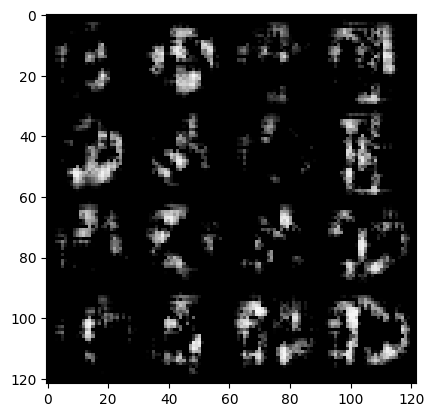

  0%|          | 0/469 [00:00<?, ?it/s]

Epoch: 2 --- D_loss: 0.6829598852312133 --- G_loss: 0.7082326996809384


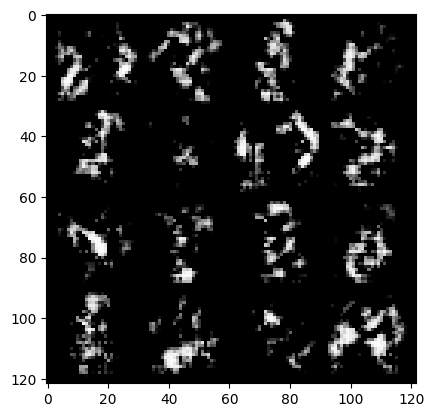

  0%|          | 0/469 [00:00<?, ?it/s]

Epoch: 3 --- D_loss: 0.6365910473662907 --- G_loss: 0.7666178097857087


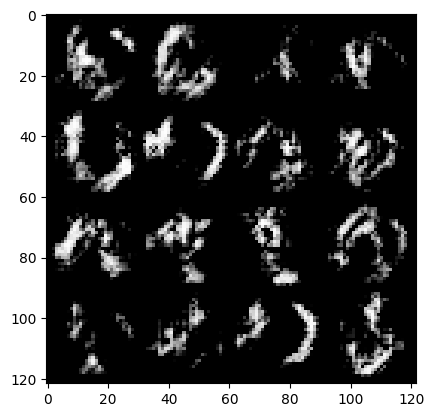

  0%|          | 0/469 [00:00<?, ?it/s]

Epoch: 4 --- D_loss: 0.5709711526756855 --- G_loss: 0.8592883356090294


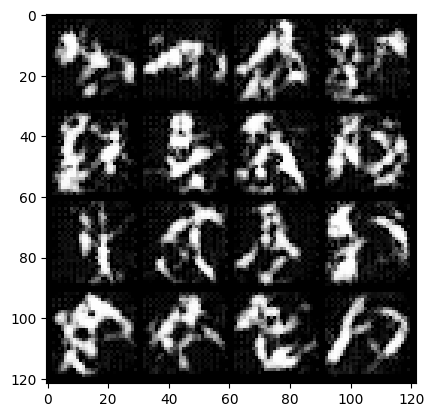

  0%|          | 0/469 [00:00<?, ?it/s]

Epoch: 5 --- D_loss: 0.5234556449120487 --- G_loss: 0.9414742899093547


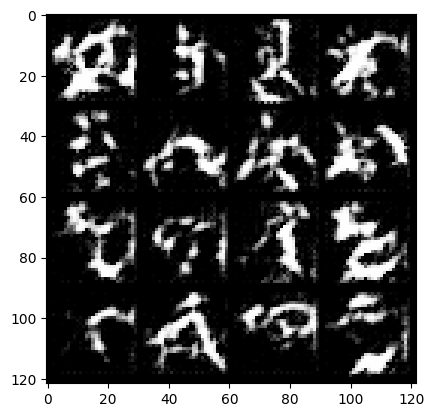

  0%|          | 0/469 [00:00<?, ?it/s]

Epoch: 6 --- D_loss: 0.5007111086392961 --- G_loss: 1.0012094044227844


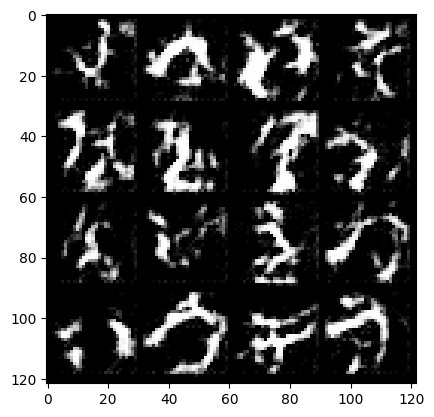

  0%|          | 0/469 [00:00<?, ?it/s]

Epoch: 7 --- D_loss: 0.5067598847692201 --- G_loss: 1.0155071396309177


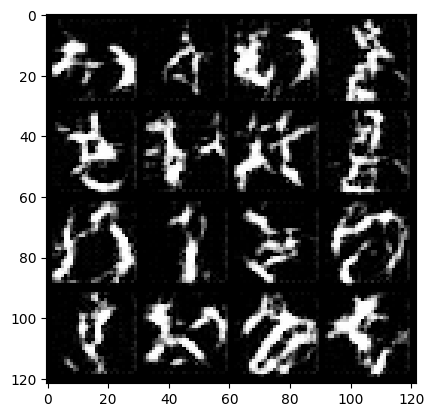

  0%|          | 0/469 [00:00<?, ?it/s]

Epoch: 8 --- D_loss: 0.5204169558944987 --- G_loss: 1.0096736812134033


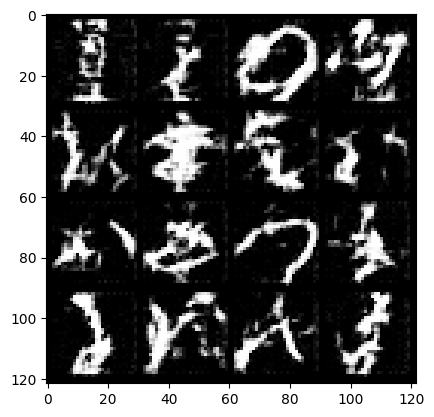

  0%|          | 0/469 [00:00<?, ?it/s]

Epoch: 9 --- D_loss: 0.5314484522032585 --- G_loss: 0.9965135314062968


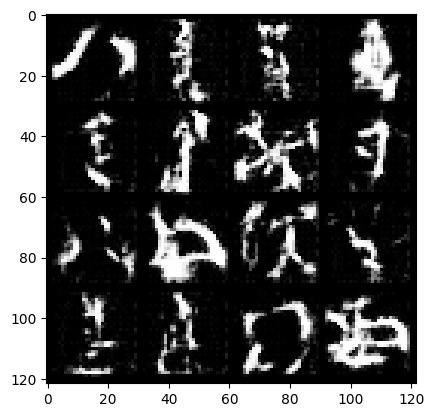

  0%|          | 0/469 [00:00<?, ?it/s]

Epoch: 10 --- D_loss: 0.5382361325627959 --- G_loss: 0.9988543947876644


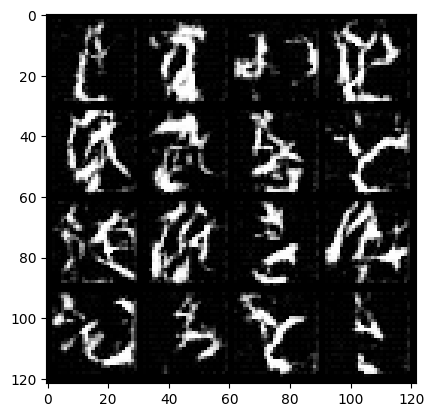

  0%|          | 0/469 [00:00<?, ?it/s]

Epoch: 11 --- D_loss: 0.545621753120219 --- G_loss: 0.9923420141754883


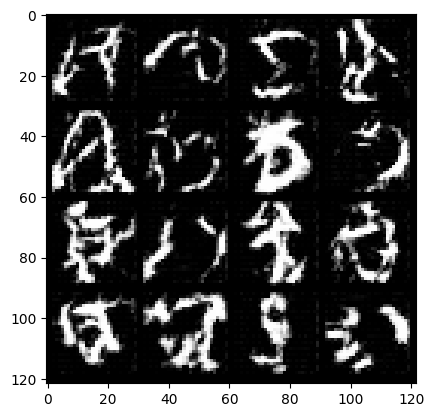

  0%|          | 0/469 [00:00<?, ?it/s]

Epoch: 12 --- D_loss: 0.5494390776289552 --- G_loss: 0.9906956863555827


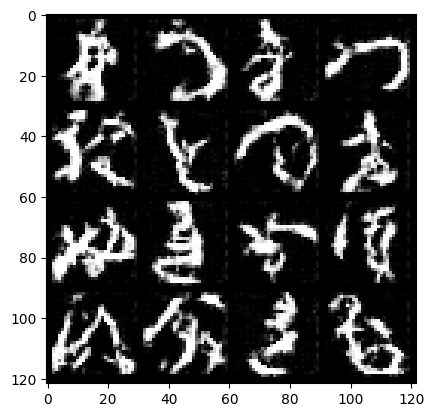

  0%|          | 0/469 [00:00<?, ?it/s]

Epoch: 13 --- D_loss: 0.552591270602334 --- G_loss: 0.9942924237962979


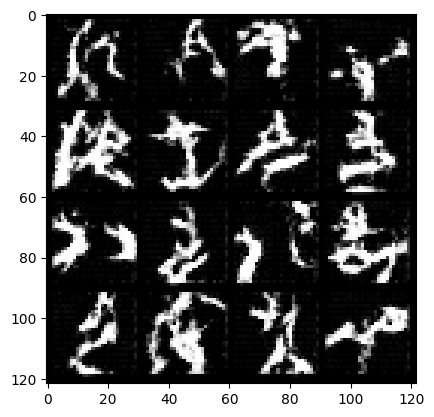

  0%|          | 0/469 [00:00<?, ?it/s]

Epoch: 14 --- D_loss: 0.5543502881837044 --- G_loss: 1.0037512550476009


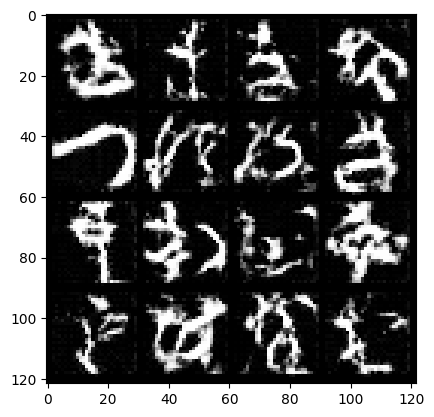

  0%|          | 0/469 [00:00<?, ?it/s]

Epoch: 15 --- D_loss: 0.5548491048406182 --- G_loss: 1.0038039783424915


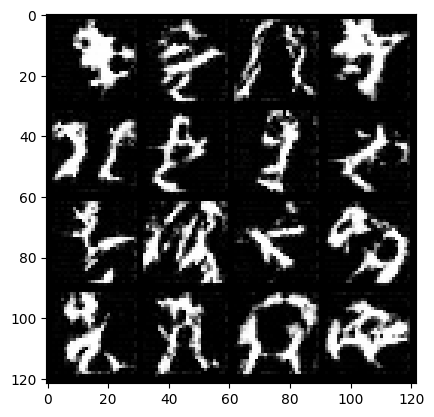

  0%|          | 0/469 [00:00<?, ?it/s]

Epoch: 16 --- D_loss: 0.5553359577396532 --- G_loss: 1.0067279811606986


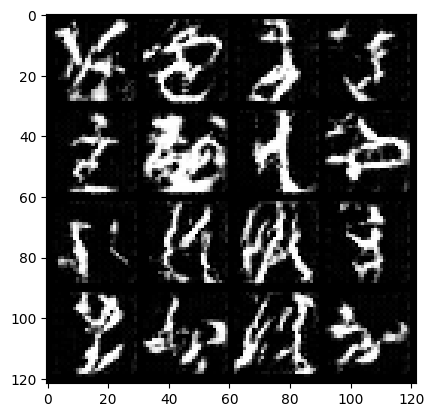

  0%|          | 0/469 [00:00<?, ?it/s]

Epoch: 17 --- D_loss: 0.5549722024753913 --- G_loss: 1.013888752028378


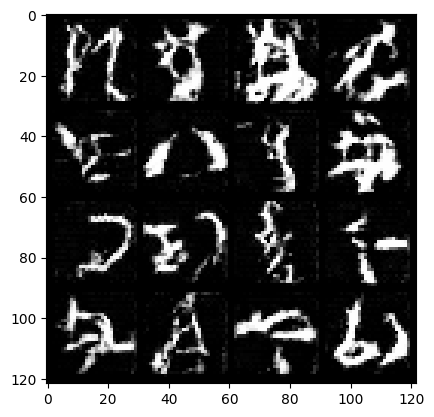

  0%|          | 0/469 [00:00<?, ?it/s]

Epoch: 18 --- D_loss: 0.5552625006704188 --- G_loss: 1.0114804633390675


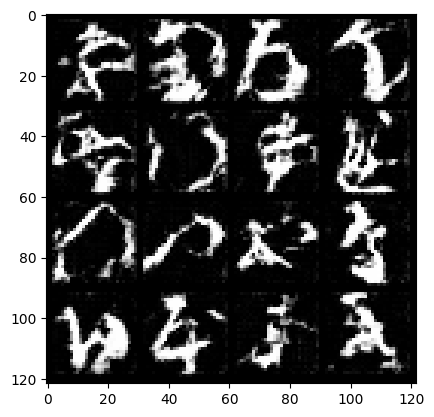

  0%|          | 0/469 [00:00<?, ?it/s]

Epoch: 19 --- D_loss: 0.5595929543855094 --- G_loss: 1.013192579944505


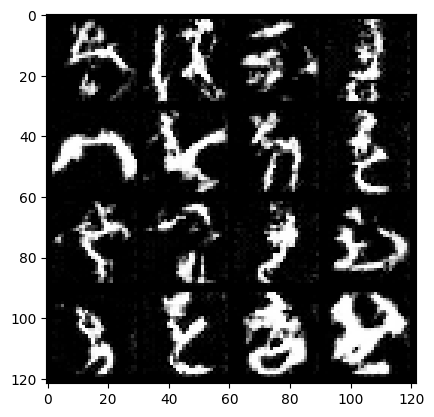

  0%|          | 0/469 [00:00<?, ?it/s]

Epoch: 20 --- D_loss: 0.5565612546797755 --- G_loss: 1.019756629141663


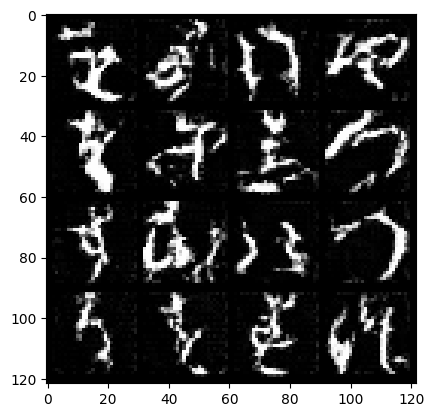

In [ ]:
from torchvision.models import inception_v3
from torch.nn.functional import softmax
from torchvision.transforms import Resize, Normalize
d_losses = []
g_losses = []

for i in range(epochs):
  total_d_loss = 0.0
  total_g_loss = 0.0

  for real_image, _ in tqdm(trainloader):
    real_image = real_image.to(gpu)

    # calculate loss and update weights for D
    D_opt.zero_grad()

    noise = torch.randn(batch_size, noise_vec_dim, device=gpu)
    fake_image = G(noise)
    D_pred = D(fake_image)
    D_fake_loss = fake_loss(D_pred)

    D_pred = D(real_image)
    D_real_loss = real_loss(D_pred)

    D_loss = (D_fake_loss + D_real_loss) / 2

    total_d_loss += D_loss.item()

    D_loss.backward()
    D_opt.step()

    # calculate loss and update weights for G
    G_opt.zero_grad()

    noise = torch.randn(batch_size, noise_vec_dim, device=gpu)
    fake_image = G(noise)
    D_pred = D(fake_image)
    G_loss = real_loss(D_pred)

    total_g_loss += G_loss.item()

    G_loss.backward()
    G_opt.step()

  avg_d_loss = total_d_loss / len(trainloader)
  avg_g_loss = total_g_loss / len(trainloader)

  d_losses.append(avg_d_loss)
  g_losses.append(avg_g_loss)

  print(f"Epoch: {i+1} --- D_loss: {avg_d_loss} --- G_loss: {avg_g_loss}")

  show_tensor_images(fake_image)

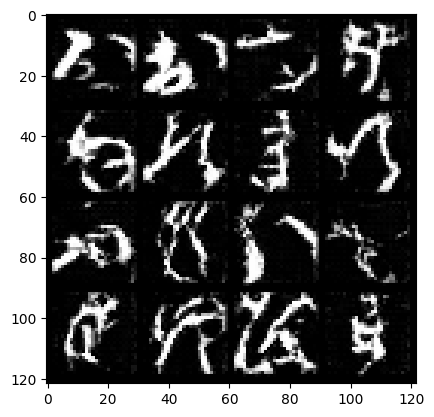

In [ ]:
# пример работы обученной сети
noise = torch.randn(batch_size, noise_vec_dim, device = gpu)
generated_image = G(noise)

show_tensor_images(generated_image)

In [ ]:
import matplotlib.pyplot as plt

print(d_losses)
print(g_losses)

Мы можем видеть, что по мере продвижения по эпохам потери дискриминатора стремятся к 1, а потери генератора держатся в районе значения 0,5